# Loading libraries and Dataset

In [334]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from statsmodels.graphics.tsaplots import month_plot, quarter_plot, plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose

In [335]:
sns.set_theme(palette='Set2',style='dark' , context='notebook')

In [336]:
path= Path(r'Sales')

In [337]:
df_list= []
for file in path.glob('*.csv'):
    df= pd.read_csv(file)
    df_list.append(df)

df= pd.concat(df_list)

In [338]:
df.head()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
0,176558,USB-C Charging Cable,2,11.95,04/19/19 08:46,"917 1st St, Dallas, TX 75001"
1,NaN,NaN,NaN,NaN,NaN,NaN
2,176559,Bose SoundSport Headphones,1,99.99,04/07/19 22:30,"682 Chestnut St, Boston, MA 02215"
3,176560,Google Phone,1,600,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001"
4,176560,Wired Headphones,1,11.99,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001"


In [339]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 186850 entries, 0 to 11685
Data columns (total 6 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   Order ID          186305 non-null  object
 1   Product           186305 non-null  object
 2   Quantity Ordered  186305 non-null  object
 3   Price Each        186305 non-null  object
 4   Order Date        186305 non-null  object
 5   Purchase Address  186305 non-null  object
dtypes: object(6)
memory usage: 10.0+ MB


In [340]:
# Checking for null values
df.isnull().sum() / len(df) * 100

Order ID            0.291678
Product             0.291678
Quantity Ordered    0.291678
Price Each          0.291678
Order Date          0.291678
Purchase Address    0.291678
dtype: float64

In [341]:
# Dropping null values
df.dropna(inplace=True, axis=0)

In [342]:
# Checking for duplicates
df.duplicated().sum()

618

In [343]:
# Dropping duplicates
df.drop_duplicates(inplace=True)

In [344]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 185687 entries, 0 to 11685
Data columns (total 6 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   Order ID          185687 non-null  object
 1   Product           185687 non-null  object
 2   Quantity Ordered  185687 non-null  object
 3   Price Each        185687 non-null  object
 4   Order Date        185687 non-null  object
 5   Purchase Address  185687 non-null  object
dtypes: object(6)
memory usage: 9.9+ MB


In [345]:

df=df[df['Order Date']!= 'Order Date']

In [346]:
#  Converting order date to the perfect format
df['Order Date']= pd.to_datetime(df['Order Date'],  format='mixed', dayfirst=True)

In [347]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 185686 entries, 0 to 11685
Data columns (total 6 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Order ID          185686 non-null  object        
 1   Product           185686 non-null  object        
 2   Quantity Ordered  185686 non-null  object        
 3   Price Each        185686 non-null  object        
 4   Order Date        185686 non-null  datetime64[ns]
 5   Purchase Address  185686 non-null  object        
dtypes: datetime64[ns](1), object(5)
memory usage: 9.9+ MB


In [348]:
# Setting order date as index
df.set_index('Order Date', inplace=True)

In [349]:
df.head()

,Order ID,Product,Quantity Ordered,Price Each,Purchase Address
Order Date,,,,,
2019-04-19 08:46:00,176558,USB-C Charging Cable,2,11.95,"917 1st St, Dallas, TX 75001"
2019-07-04 22:30:00,176559,Bose SoundSport Headphones,1,99.99,"682 Chestnut St, Boston, MA 02215"
2019-12-04 14:38:00,176560,Google Phone,1,600,"669 Spruce St, Los Angeles, CA 90001"
2019-12-04 14:38:00,176560,Wired Headphones,1,11.99,"669 Spruce St, Los Angeles, CA 90001"
2019-04-30 09:27:00,176561,Wired Headphones,1,11.99,"333 8th St, Los Angeles, CA 90001"


In [350]:
# Sorting data based on index
df.sort_index(inplace=True)

In [351]:
df.head()

,Order ID,Product,Quantity Ordered,Price Each,Purchase Address
Order Date,,,,,
2019-01-01 03:07:00,147268,Wired Headphones,1,11.99,"9 Lake St, New York City, NY 10001"
2019-01-01 03:40:00,148041,USB-C Charging Cable,1,11.95,"760 Church St, San Francisco, CA 94016"
2019-01-01 04:56:00,149343,Apple Airpods Headphones,1,150,"735 5th St, New York City, NY 10001"
2019-01-01 05:53:00,149964,AAA Batteries (4-pack),1,2.99,"75 Jackson St, Dallas, TX 75001"
2019-01-01 06:03:00,149350,USB-C Charging Cable,2,11.95,"943 2nd St, Atlanta, GA 30301"


In [352]:
df.dtypes

Order ID            object
Product             object
Quantity Ordered    object
Price Each          object
Purchase Address    object
dtype: object

In [353]:
# fixing datatypes
df['Order ID']= df['Order ID'].astype('int64')
df['Price Each']= df['Price Each'].astype('float64')
df['Quantity Ordered']= df['Quantity Ordered'].astype('int64')

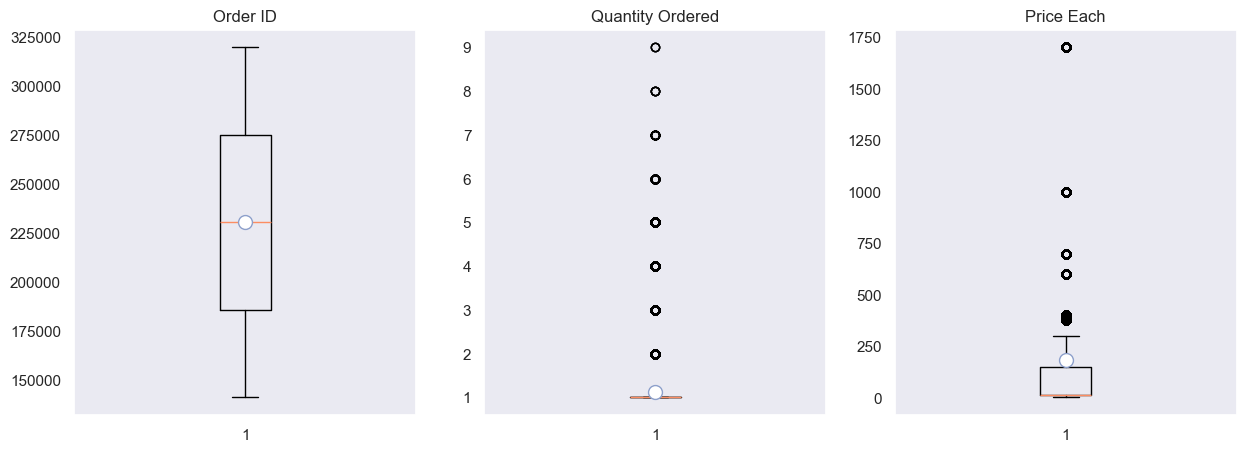

In [354]:
#  Visualizing distributions to find outliers

fig,axes= plt.subplots(1,3, figsize=(15,5))

axes= axes.reshape(-1)

for i,col in enumerate(df.select_dtypes(include=np.number)):
  axes[i].boxplot(df[col], showmeans=True,
                  meanprops= {
                    "marker": "o",
                    "markerfacecolor": "White",
                    "markersize": "10"
                },)
  axes[i].set_title(col)
plt.show()

In [355]:
df[df['Quantity Ordered']==5].sample(10)

,Order ID,Product,Quantity Ordered,Price Each,Purchase Address
Order Date,,,,,
2019-12-22 20:12:00,317095,AAA Batteries (4-pack),5,2.99,"4 Adams St, Boston, MA 02215"
2019-09-22 11:26:00,249172,AA Batteries (4-pack),5,3.84,"826 Spruce St, Los Angeles, CA 90001"
2019-03-11 12:50:00,285720,AAA Batteries (4-pack),5,2.99,"601 Wilson St, Dallas, TX 75001"
2019-12-14 16:45:00,317152,AAA Batteries (4-pack),5,2.99,"11 1st St, Atlanta, GA 30301"
2019-12-25 19:50:00,302889,AAA Batteries (4-pack),5,2.99,"437 Hill St, Austin, TX 73301"
2019-08-03 20:47:00,169604,AAA Batteries (4-pack),5,2.99,"940 Park St, Portland, OR 97035"
2019-09-11 18:14:00,284058,AAA Batteries (4-pack),5,2.99,"982 Church St, Los Angeles, CA 90001"
2019-02-25 05:54:00,152611,AAA Batteries (4-pack),5,2.99,"15 Chestnut St, Boston, MA 02215"
2019-06-19 12:34:00,219634,AAA Batteries (4-pack),5,2.99,"191 14th St, Los Angeles, CA 90001"


In [356]:
df[df['Price Each']>= 250].sample(10)

,Order ID,Product,Quantity Ordered,Price Each,Purchase Address
Order Date,,,,,
2019-09-17 23:25:00,253367,Vareebadd Phone,1,400.00,"284 Willow St, San Francisco, CA 94016"
2019-04-18 20:25:00,187198,34in Ultrawide Monitor,1,379.99,"987 Chestnut St, New York City, NY 10001"
2019-04-28 09:34:00,183404,Macbook Pro Laptop,1,1700.00,"962 Maple St, Seattle, WA 98101"
2019-05-27 19:15:00,208932,ThinkPad Laptop,1,999.99,"888 Cedar St, New York City, NY 10001"
2019-05-16 12:51:00,207511,iPhone,1,700.00,"412 Park St, Seattle, WA 98101"
2019-05-20 12:24:00,203477,34in Ultrawide Monitor,1,379.99,"704 Hickory St, Dallas, TX 75001"
2019-04-29 13:55:00,182956,Macbook Pro Laptop,1,1700.00,"740 Meadow St, Dallas, TX 75001"
2019-01-02 17:29:00,151170,34in Ultrawide Monitor,1,379.99,"625 Park St, Boston, MA 02215"
2019-04-07 15:43:00,234318,iPhone,1,700.00,"417 Church St, Boston, MA 02215"


> Notice most of the items more than $250 are expensive items thus are not necessary outliesr same with the number of quantity ordered

In [357]:
df.head()

,Order ID,Product,Quantity Ordered,Price Each,Purchase Address
Order Date,,,,,
2019-01-01 03:07:00,147268,Wired Headphones,1,11.99,"9 Lake St, New York City, NY 10001"
2019-01-01 03:40:00,148041,USB-C Charging Cable,1,11.95,"760 Church St, San Francisco, CA 94016"
2019-01-01 04:56:00,149343,Apple Airpods Headphones,1,150.00,"735 5th St, New York City, NY 10001"
2019-01-01 05:53:00,149964,AAA Batteries (4-pack),1,2.99,"75 Jackson St, Dallas, TX 75001"
2019-01-01 06:03:00,149350,USB-C Charging Cable,2,11.95,"943 2nd St, Atlanta, GA 30301"


In [358]:
df['Total_sales_price']= df['Quantity Ordered'] * df['Price Each']
df['purchase_city']= df['Purchase Address'].str.split(',').str.get(1)
df['postal_code']= df['Purchase Address'].str.slice(-5)
df['State']= df['Purchase Address'].str.slice(start=-8, stop=-6)

In [359]:
df['day']= df.index.day_name()
df['month']= df.index.month_name()
df['year']= df.index.year
df['time']= df.index.time
df.index= df.index.date

In [360]:
df.sample(5)

,Order ID,Product,Quantity Ordered,Price Each,Purchase Address,Total_sales_price,purchase_city,postal_code,State,day,month,year,time
2019-04-12,317129,Lightning Charging Cable,1,14.95,"535 Maple St, Los Angeles, CA 90001",14.95,Los Angeles,90001,CA,Friday,April,2019,03:38:00
2019-05-24,198114,20in Monitor,1,109.99,"897 Maple St, San Francisco, CA 94016",109.99,San Francisco,94016,CA,Friday,May,2019,19:17:00
2019-11-03,162438,Lightning Charging Cable,1,14.95,"187 South St, San Francisco, CA 94016",14.95,San Francisco,94016,CA,Sunday,November,2019,22:03:00
2019-06-21,215184,Macbook Pro Laptop,1,1700.00,"17 Dogwood St, Austin, TX 73301",1700.00,Austin,73301,TX,Friday,June,2019,17:16:00
2019-09-06,221603,Lightning Charging Cable,1,14.95,"511 14th St, Austin, TX 73301",14.95,Austin,73301,TX,Friday,September,2019,16:09:00


In [361]:
df.dtypes

Order ID               int64
Product               object
Quantity Ordered       int64
Price Each           float64
Purchase Address      object
Total_sales_price    float64
purchase_city         object
postal_code           object
State                 object
day                   object
month                 object
year                   int32
time                  object
dtype: object

In [362]:
df.index= pd.to_datetime(df.index, dayfirst=True)

In [363]:
df.index

DatetimeIndex(['2019-01-01', '2019-01-01', '2019-01-01', '2019-01-01',
               '2019-01-01', '2019-01-01', '2019-01-01', '2019-01-01',
               '2019-01-01', '2019-01-01',
               ...
               '2020-01-01', '2020-01-01', '2020-01-01', '2020-01-01',
               '2020-01-01', '2020-01-01', '2020-01-01', '2020-01-01',
               '2020-01-01', '2020-01-01'],
              dtype='datetime64[ns]', length=185686, freq=None)

# Eda and Visualizations

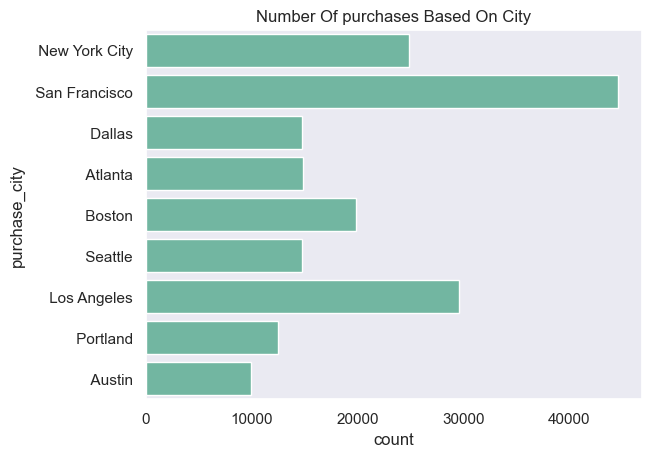

In [364]:
plt.Figure(figsize=(6.4, 4.6))

sns.countplot(data=df, y= 'purchase_city')
plt.title('Number Of purchases Based On City')

plt.show()

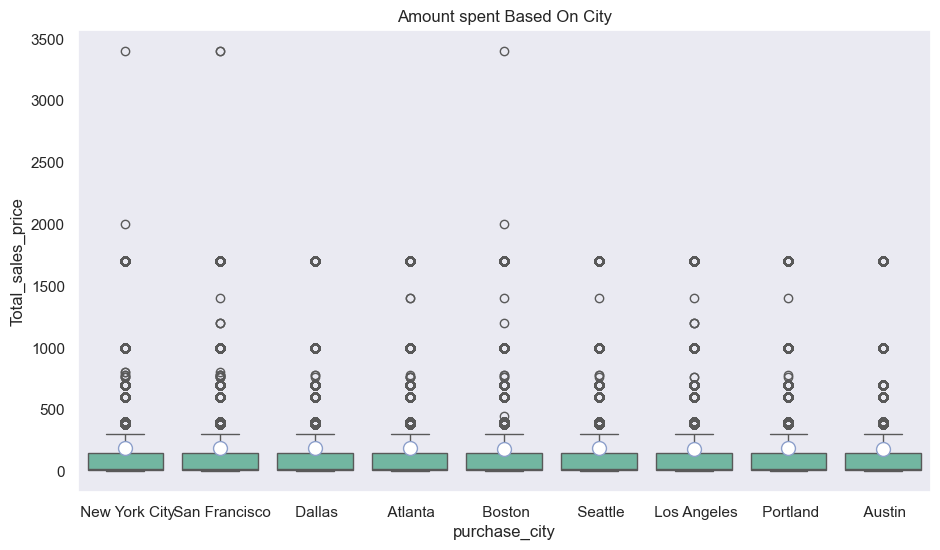

In [365]:
plt.figure(figsize=(11,6))


sns.boxplot(data=df,y='Total_sales_price', x='purchase_city', showmeans= True,
            meanprops= {
                    "marker": "o",
                    "markerfacecolor": "White",
                    "markersize": "10"
                } )



plt.title('Amount spent Based On City')
plt.show()

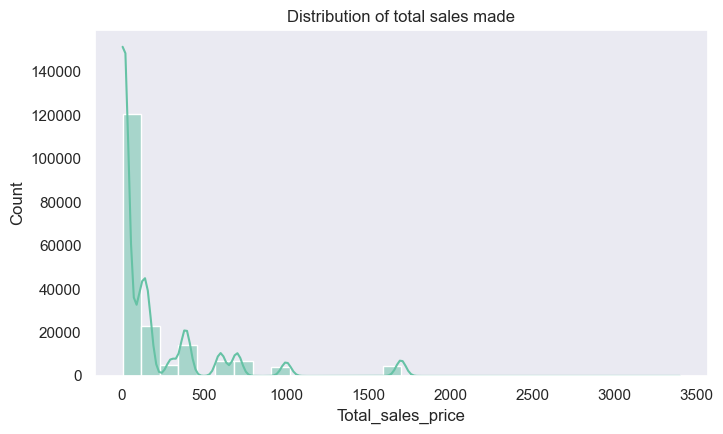

In [366]:
plt.figure(figsize=(7.4,4.5))

sns.histplot(data=df, x='Total_sales_price', kde=True, bins=30)

plt.title('Distribution of total sales made')

plt.tight_layout()
plt.show()

In [367]:
df[df['Total_sales_price']> 1200]['Product'].value_counts()

Product
Macbook Pro Laptop    4721
iPhone                   7
ThinkPad Laptop          2
Name: count, dtype: int64

> i phone and laptop rank amoung products that costs $1200 and above

In [368]:
df.query(" Total_sales_price >= 800 and  Total_sales_price <= 1100")['Product'].value_counts()

Product
ThinkPad Laptop    4124
Vareebadd Phone       3
Name: count, dtype: int64

Think pad laptop and Vareebadd Phone rank amoung product of price ranging from $ 800 till $1100

In [369]:
df.query("Total_sales_price >= 500 and Total_sales_price <=800")['Product'].value_counts()

Product
iPhone                    6833
Google Phone              5515
LG Washing Machine         666
LG Dryer                   646
Flatscreen TV               19
34in Ultrawide Monitor      18
27in 4K Gaming Monitor      14
Vareebadd Phone              3
Name: count, dtype: int64

In [370]:
df.groupby('purchase_city')[['Quantity Ordered','Total_sales_price']].agg(['mean','count', 'sum'])

Quantity Ordered               Total_sales_price         \
                          mean  count    sum              mean  count   
purchase_city                                                           
Atlanta               1.115791  14863  16584        187.996977  14863   
Austin                1.126087   9890  11137        183.826525   9890   
Boston                1.130295  19901  22494        183.841397  19901   
Dallas                1.129080  14797  16707        186.887474  14797   
Los Angeles           1.124577  29564  33247        184.288468  29564   
New York City         1.122993  24847  27903        187.622938  24847   
Portland              1.127560  12449  14037        186.306686  12449   
San Francisco         1.123304  44662  50169        184.827002  44662   
Seattle               1.123768  14713  16534        186.572828  14713   

                           
                      sum  
purchase_city              
Atlanta        2794199.07  
Austin         1818044.33  
Boston         3658627.65  
Dallas         2765373.96  
Los Angeles    5448304.28  
New York City  4661867.14  
Portland       2319331.94  
San Francisco  8254743.55  
Seattle        2745046.02

* San francisco emerge as the city with the most product sold and revenue generated followed by los angeles and new york
* Atalanta has the highest average total sales price while bostn has the highest average quantity ordered 
* Autin is the weakest in the market

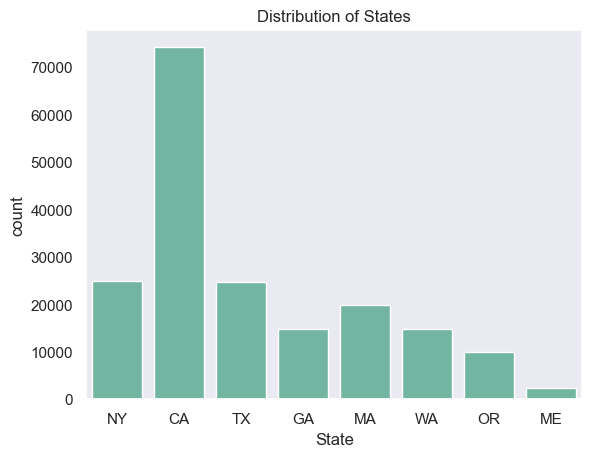

In [371]:
plt.Figure(figsize=(6.4,4.5))

sns.countplot(data=df, x='State')

plt.title('Distribution of States')

plt.show()

In [372]:
df.groupby('State')[['Quantity Ordered','Total_sales_price']].agg(['mean','count', 'sum'])

Quantity Ordered               Total_sales_price                    
                  mean  count    sum              mean  count          sum
State                                                                     
CA            1.123811  74226  83416        184.612505  74226  13703047.83
GA            1.115791  14863  16584        187.996977  14863   2794199.07
MA            1.130295  19901  22494        183.841397  19901   3658627.65
ME            1.120359   2451   2746        183.321656   2451    449321.38
NY            1.122993  24847  27903        187.622938  24847   4661867.14
OR            1.129326   9998  11291        187.038464   9998   1870010.56
TX            1.127881  24687  27844        185.661210  24687   4583418.29
WA            1.123768  14713  16534        186.572828  14713   2745046.02

In [373]:
df.groupby('day')[['Total_sales_price','Quantity Ordered']].agg(['mean','sum','count'])

Total_sales_price                    Quantity Ordered              
                       mean         sum  count             mean    sum  count
day                                                                          
Friday           187.287109  4916661.19  26252         1.123076  29483  26252
Monday           186.700652  4919375.49  26349         1.124065  29618  26349
Saturday         183.035642  4823355.25  26352         1.126404  29683  26352
Sunday           184.122986  4883678.08  26524         1.122040  29761  26524
Thursday         183.711858  4915761.90  26758         1.122655  30040  26758
Tuesday          187.543930  5102507.71  27207         1.126585  30651  27207
Wednesday        186.869316  4904198.32  26244         1.126962  29576  26244

In [374]:
df.groupby('month')[['Total_sales_price','Quantity Ordered']].agg(['mean','sum','count'])

Total_sales_price                    Quantity Ordered              
                       mean         sum  count             mean    sum  count
month                                                                        
April            189.937717  3228561.31  16998         1.125250  19127  16998
August           181.931256  2442972.91  13428         1.123324  15084  13428
December         182.048136  3921316.86  21540         1.133008  24405  21540
February         183.250298  2393981.89  13064         1.126148  14712  13064
January          190.116375  2284818.59  12018         1.130138  13582  12018
July             184.145990  2719467.98  14768         1.123713  16595  14768
June             188.631988  2683101.40  14224         1.117196  15891  14224
March            185.523824  2791020.41  15044         1.123704  16905  15044
May              187.268636  3031130.14  16186         1.132089  18324  16186
November         185.633289  3084853.99  16618         1.118005  18579  16618
October          185.478784  3473646.66  18728         1.117258  20924  18728
September        184.442678  2410665.80  13070         1.123489  14684  13070

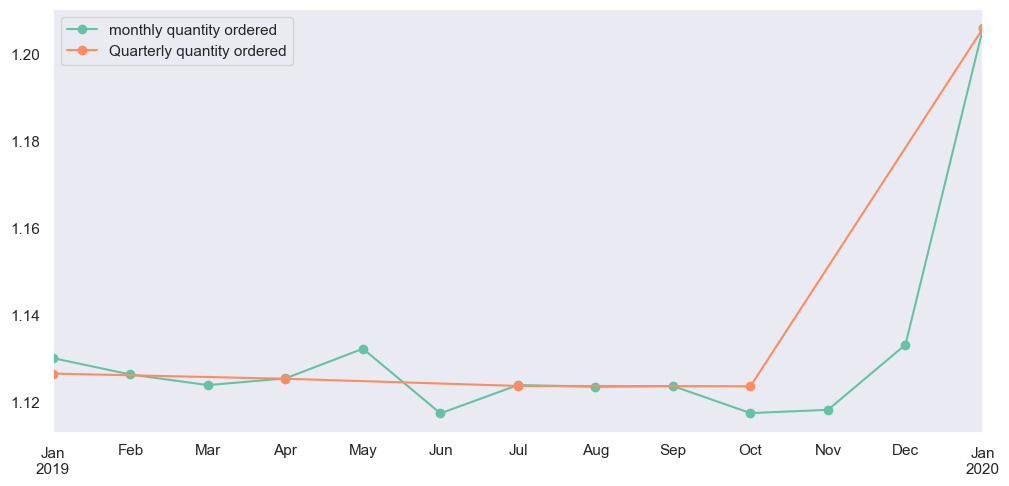

In [375]:
plt.figure(figsize=(12,5.5))
df['Quantity Ordered'].resample('ME').mean().plot(label= 'monthly quantity ordered', marker='o')
df['Quantity Ordered'].resample('QE').mean().plot(label= 'Quarterly quantity ordered', marker='o')

plt.legend()
plt.show()

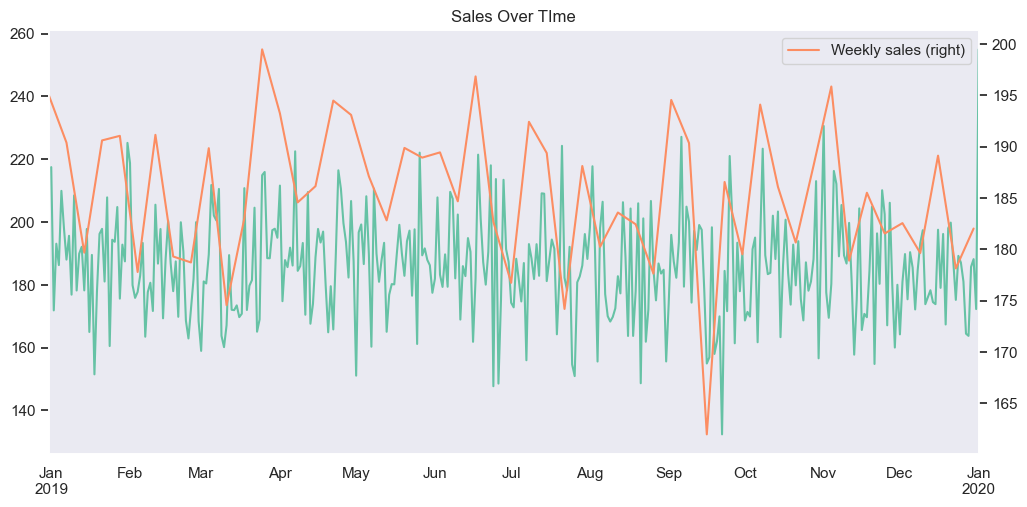

In [376]:
plt.figure(figsize=(12,5.5))

df.Total_sales_price.resample('D').mean().plot(label= 'Daily sales')
df.Total_sales_price.resample('W').mean().plot(label= 'Weekly sales', secondary_y=True)


plt.title('Sales Over TIme')
plt.legend()
plt.show()

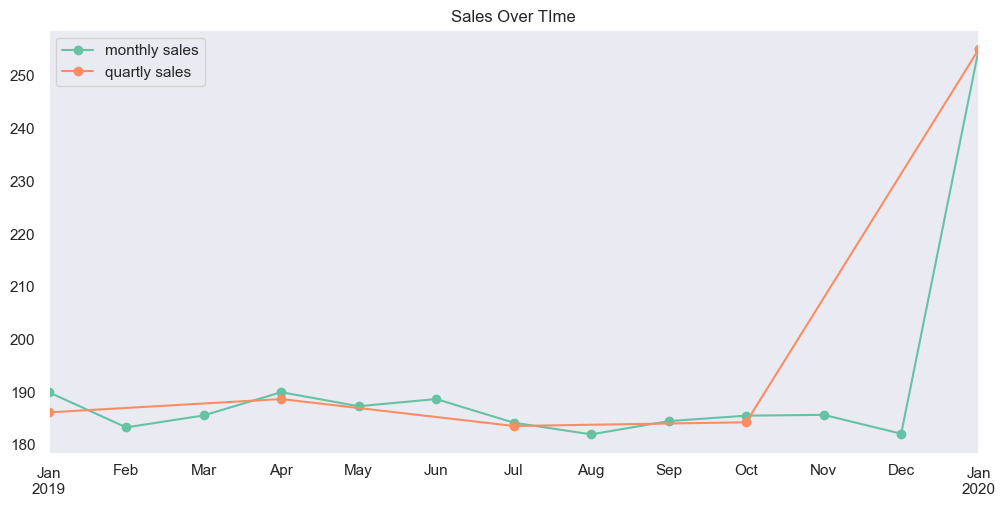

In [377]:
plt.figure(figsize=(12,5.5))
df.Total_sales_price.resample('ME').mean().plot(label= 'monthly sales', marker='o')
df.Total_sales_price.resample('QE').mean().plot(label= 'quartly sales', marker='o')


plt.title('Sales Over TIme')
plt.legend()
plt.show()

> quater 4 the strongest period for total sales and quantity ordered with december standing out as the peak 

In [378]:
decompose= seasonal_decompose(x=df.Total_sales_price,model='mul', period=365,extrapolate_trend='freq')

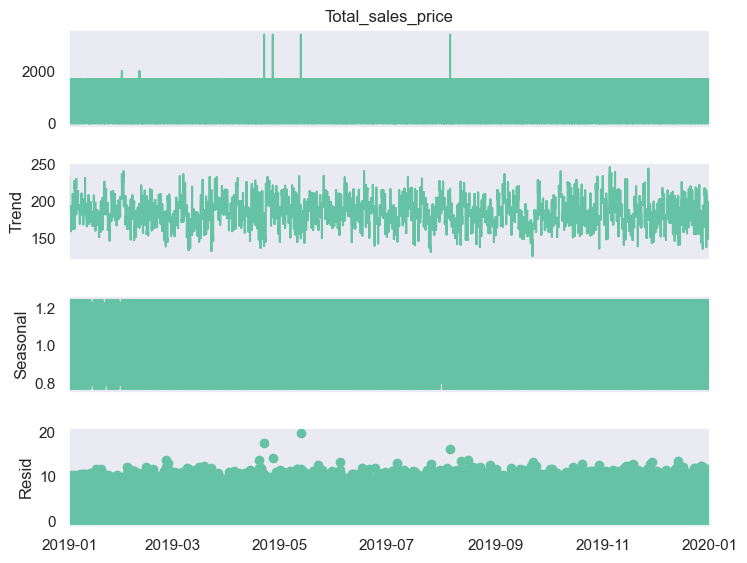

In [379]:
decompose.plot().set_size_inches(8,6)

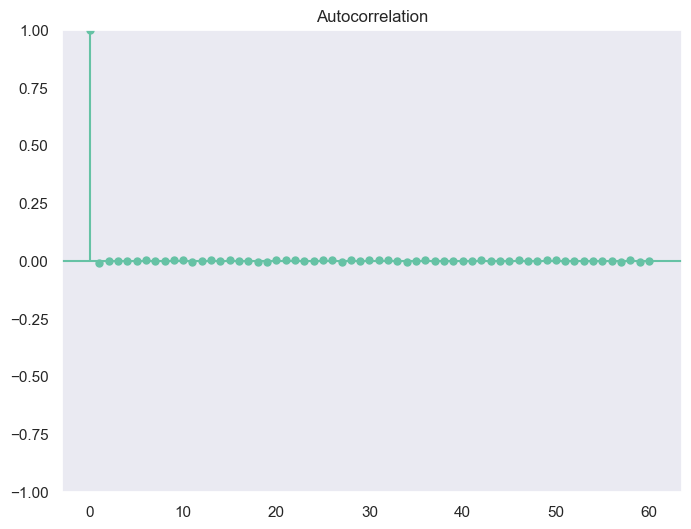

In [380]:
plot_acf(df.Total_sales_price, lags=60).set_size_inches(8,6)

plt.show()

[]

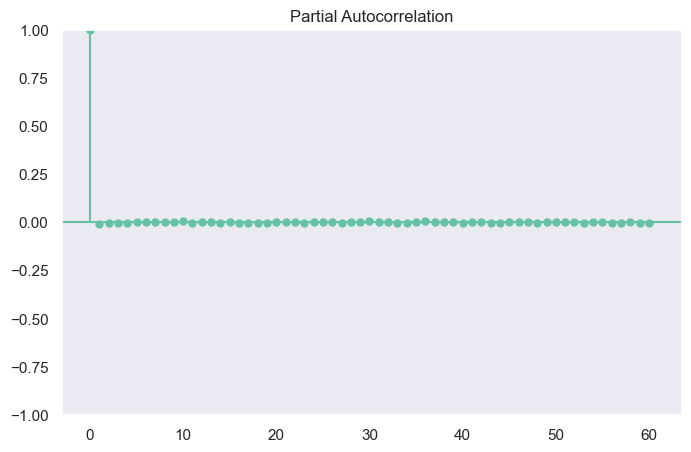

In [381]:
plot_pacf(df.Total_sales_price, lags=60).set_size_inches(8,5)
plt.plot()

In [382]:
df['Order ID'].value_counts().head()

Order ID
160873    5
289117    4
235798    4
194253    4
193511    4
Name: count, dtype: int64

In [383]:
df[df['Order ID']== 160873 ]

,Order ID,Product,Quantity Ordered,Price Each,Purchase Address,Total_sales_price,purchase_city,postal_code,State,day,month,year,time
2019-10-02,160873,Wired Headphones,1,11.99,"702 River St, San Francisco, CA 94016",11.99,San Francisco,94016,CA,Wednesday,October,2019,10:24:00
2019-10-02,160873,Apple Airpods Headphones,1,150.00,"702 River St, San Francisco, CA 94016",150.00,San Francisco,94016,CA,Wednesday,October,2019,10:24:00
2019-10-02,160873,Google Phone,1,600.00,"702 River St, San Francisco, CA 94016",600.00,San Francisco,94016,CA,Wednesday,October,2019,10:24:00
2019-10-02,160873,iPhone,1,700.00,"702 River St, San Francisco, CA 94016",700.00,San Francisco,94016,CA,Wednesday,October,2019,10:24:00
2019-10-02,160873,Lightning Charging Cable,1,14.95,"702 River St, San Francisco, CA 94016",14.95,San Francisco,94016,CA,Wednesday,October,2019,10:24:00


order id 160873 ordered the most product at a go

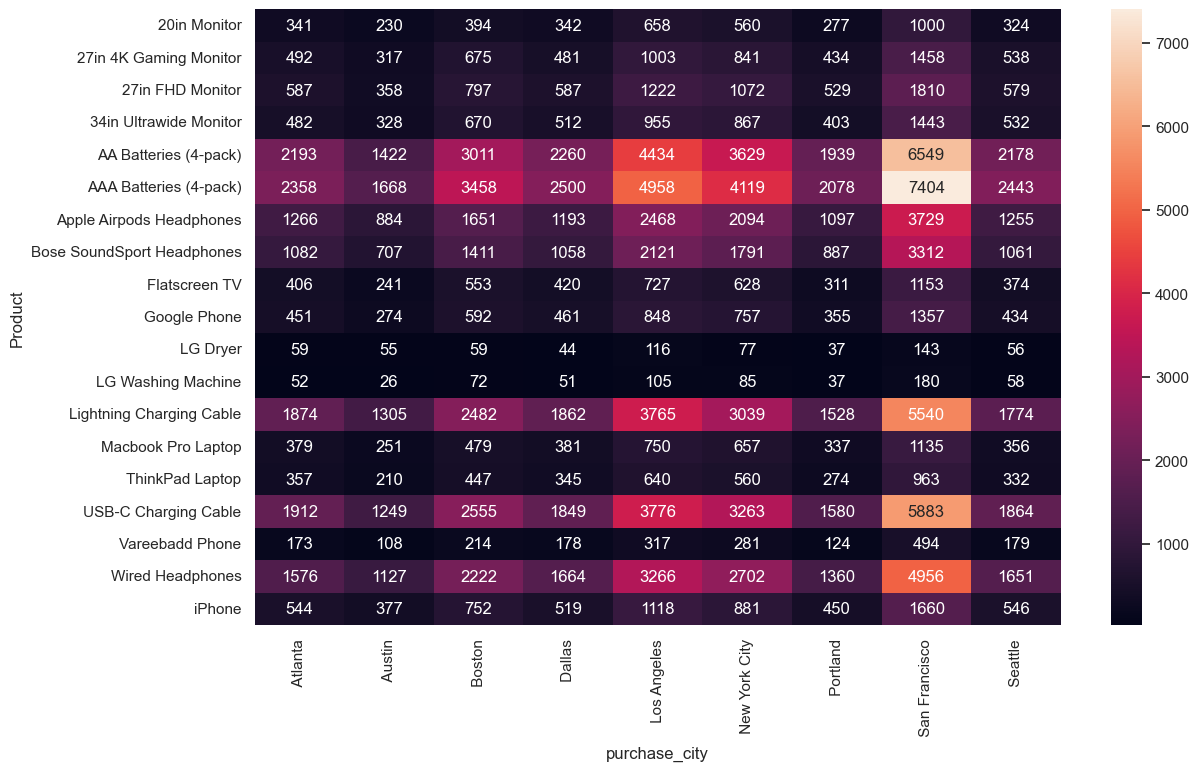

In [384]:
# Quantity of products ordered by city

city_product=df.pivot_table(index='Product', columns='purchase_city', values='Quantity Ordered', aggfunc='sum')
plt.figure(figsize=(13,8))
sns.heatmap(city_product, annot=True, fmt='')
plt.show()

In [385]:
df.groupby('Product')['Quantity Ordered'].sum().reset_index().sort_values('Quantity Ordered', ascending=False)

,Product,Quantity Ordered
5,AAA Batteries (4-pack),30986
4,AA Batteries (4-pack),27615
15,USB-C Charging Cable,23931
12,Lightning Charging Cable,23169
17,Wired Headphones,20524
6,Apple Airpods Headphones,15637
7,Bose SoundSport Headphones,13430
2,27in FHD Monitor,7541
18,iPhone,6847
1,27in 4K Gaming Monitor,6239


> Batteries, charging cables and wired headphones were the most odered products in the distribution. note the cheaper the product the more quantity ordered 

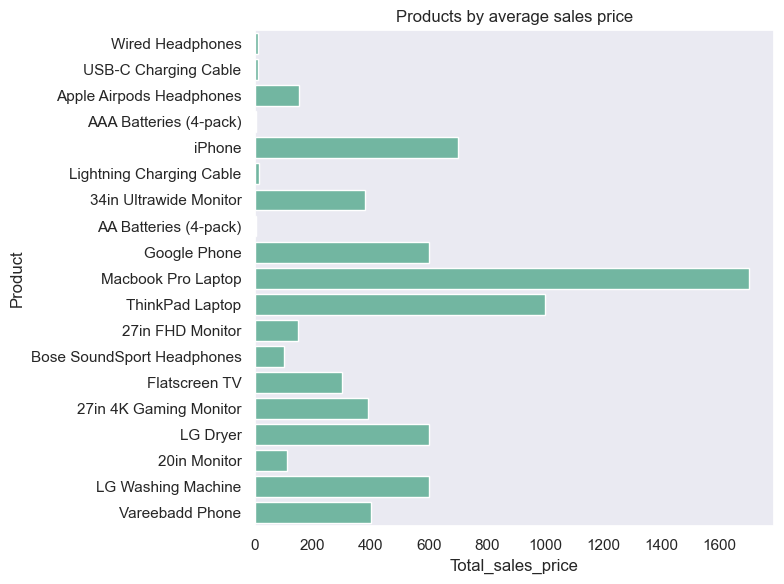

In [386]:
plt.figure(figsize=(8,6))
sns.barplot(data=df, y='Product', x='Total_sales_price', estimator='mean', errorbar=None)

plt.title('Products by average sales price')
plt.tight_layout()
plt.show()

> Laptops accumulate the most revenue in sales with batteries accumulating the least average 

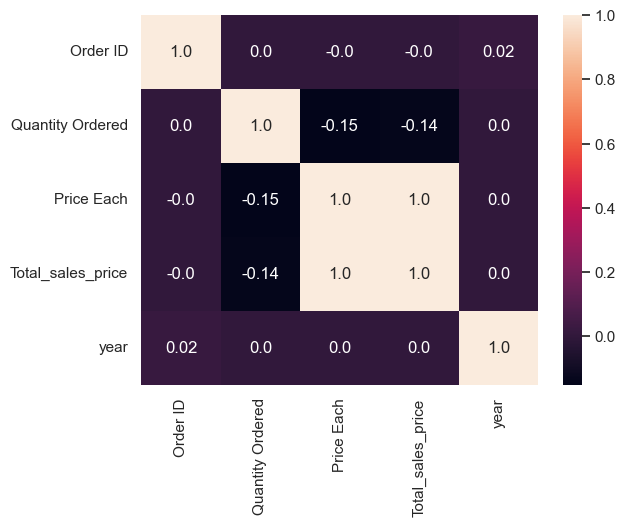

In [387]:
corr= df.select_dtypes(include=np.number).corr()

sns.heatmap(round(corr, 2), annot=True, fmt='')
plt.show()

In [388]:
for i in df.month.unique():
  data= df[df['month']== i]
  print(data.groupby(['month', 'Product'])['Quantity Ordered'].sum().reset_index().sort_values('Quantity Ordered', ascending=False).head(3))

      month                 Product  Quantity Ordered
5   January  AAA Batteries (4-pack)              1992
4   January   AA Batteries (4-pack)              1782
15  January    USB-C Charging Cable              1644
       month                 Product  Quantity Ordered
5   February  AAA Batteries (4-pack)              2176
4   February   AA Batteries (4-pack)              1942
15  February    USB-C Charging Cable              1710
    month                 Product  Quantity Ordered
5   March  AAA Batteries (4-pack)              2467
4   March   AA Batteries (4-pack)              2183
15  March    USB-C Charging Cable              1897
    month                   Product  Quantity Ordered
5   April    AAA Batteries (4-pack)              2793
4   April     AA Batteries (4-pack)              2610
12  April  Lightning Charging Cable              2176
   month                   Product  Quantity Ordered
5    May    AAA Batteries (4-pack)              2916
4    May     AA Batteries (4-pack)

> batteries and charging cables are the most product ordered by monthm

In [389]:
for i in df.purchase_city.unique():
  data= df[df['purchase_city']== i]
  print(data.groupby(['purchase_city', 'Product'])['Quantity Ordered'].sum().reset_index().sort_values('Quantity Ordered', ascending=False).head(3))

     purchase_city                 Product  Quantity Ordered
5    New York City  AAA Batteries (4-pack)              4119
4    New York City   AA Batteries (4-pack)              3629
15   New York City    USB-C Charging Cable              3263
     purchase_city                 Product  Quantity Ordered
5    San Francisco  AAA Batteries (4-pack)              7404
4    San Francisco   AA Batteries (4-pack)              6549
15   San Francisco    USB-C Charging Cable              5883
   purchase_city                   Product  Quantity Ordered
5         Dallas    AAA Batteries (4-pack)              2500
4         Dallas     AA Batteries (4-pack)              2260
12        Dallas  Lightning Charging Cable              1862
   purchase_city                 Product  Quantity Ordered
5        Atlanta  AAA Batteries (4-pack)              2358
4        Atlanta   AA Batteries (4-pack)              2193
15       Atlanta    USB-C Charging Cable              1912
   purchase_city                

> batteries and charing cables are the product with the most demand in most of the city

In [390]:
df.time.value_counts().head(20)

time
11:58:00    251
19:20:00    246
19:15:00    243
20:13:00    242
13:25:00    240
19:01:00    239
19:48:00    239
12:21:00    239
19:46:00    239
19:36:00    238
20:11:00    237
19:47:00    236
19:09:00    236
13:01:00    234
18:56:00    234
18:35:00    233
19:31:00    233
13:04:00    233
18:50:00    232
12:07:00    232
Name: count, dtype: int64

> lots of orders came in between 7 and 8 in the evening and 11 till 1 in the afternoon

In [391]:
for i in df.purchase_city.unique():
  data= df[df['purchase_city']== i]
  print(data.groupby(['purchase_city', 'Product'])['Total_sales_price'].sum().reset_index().sort_values('Total_sales_price', ascending=False).head(3))

     purchase_city             Product  Total_sales_price
13   New York City  Macbook Pro Laptop          1116900.0
18   New York City              iPhone           616700.0
14   New York City     ThinkPad Laptop           559994.4
     purchase_city             Product  Total_sales_price
13   San Francisco  Macbook Pro Laptop         1929500.00
18   San Francisco              iPhone         1162000.00
14   San Francisco     ThinkPad Laptop          962990.37
   purchase_city             Product  Total_sales_price
13        Dallas  Macbook Pro Laptop          647700.00
18        Dallas              iPhone          363300.00
14        Dallas     ThinkPad Laptop          344996.55
   purchase_city             Product  Total_sales_price
13       Atlanta  Macbook Pro Laptop          644300.00
18       Atlanta              iPhone          380800.00
14       Atlanta     ThinkPad Laptop          356996.43
   purchase_city             Product  Total_sales_price
13        Boston  Macbook Pro La

> laptop is the product with the most revenue in most statesm

In [392]:
# What percentage of the Total Revenue comes from the top 5 product

total_revenue= df.Total_sales_price.sum()

top_5_product = df.groupby('Product')['Total_sales_price'].sum().reset_index().sort_values('Total_sales_price',ascending=False).head()
top_5_revenue= top_5_product.Total_sales_price.sum()

percentage= (top_5_revenue/total_revenue) * 100

print(f'The top 5 revenue by product makes {round(percentage,2)} % of the total revenue')

The top 5 revenue by product makes 65.87 % of the total revenue


In [393]:
df.postal_code.corr(df.Total_sales_price)

-0.0010498248484851732

> No significant relationship between postal code and total sales price

In [394]:
product=df.groupby('Order ID')['Product'].sum().reset_index().sort_values('Product', ascending=False)
product.Product.unique()

array(['iPhoneWired HeadphonesLightning Charging CableUSB-C Charging Cable',
       'iPhoneWired HeadphonesLightning Charging Cable',
       'iPhoneWired HeadphonesApple Airpods HeadphonesLightning Charging Cable',
       'iPhoneWired HeadphonesApple Airpods Headphones',
       'iPhoneWired Headphones', 'iPhoneVareebadd PhoneWired Headphones',
       'iPhoneVareebadd PhoneLightning Charging Cable',
       'iPhoneVareebadd Phone', 'iPhoneUSB-C Charging Cable',
       'iPhoneThinkPad Laptop', 'iPhoneMacbook Pro Laptop',
       'iPhoneLightning Charging CableWired Headphones',
       'iPhoneLightning Charging CableApple Airpods HeadphonesWired Headphones',
       'iPhoneLightning Charging CableApple Airpods Headphones',
       'iPhoneLightning Charging CableAAA Batteries (4-pack)',
       'iPhoneLightning Charging Cable27in 4K Gaming Monitor',
       'iPhoneLightning Charging Cable', 'iPhoneGoogle Phone',
       'iPhoneFlatscreen TV', 'iPhoneBose SoundSport Headphones',
       'iPhoneAppl

In [395]:
product.Product.value_counts().reset_index().sort_values('count', ascending=False).head(20)

,Product,count
0,Lightning Charging Cable,19876
1,AAA Batteries (4-pack),19855
2,USB-C Charging Cable,19834
3,AA Batteries (4-pack),19828
4,Wired Headphones,17240
5,Apple Airpods Headphones,14599
6,Bose SoundSport Headphones,12532
7,27in FHD Monitor,7222
8,27in 4K Gaming Monitor,5984
9,34in Ultrawide Monitor,5942


> Lightning Charging Cable and iPhone are the prducts that are ordered together mostly

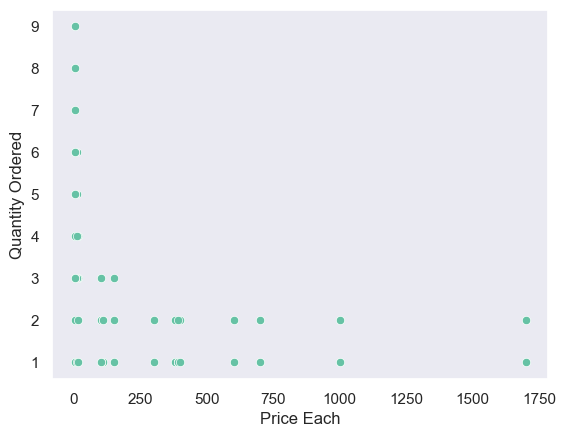

In [396]:
sns.scatterplot(data=df, x='Price Each', y='Quantity Ordered')

plt.show()

> products with most quantity ordered are within the 100$ to $200 price range

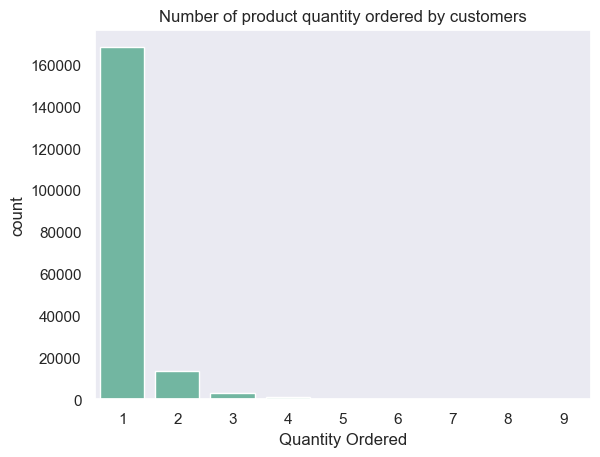

In [397]:
sns.barplot(df['Quantity Ordered'].value_counts())

plt.title("Number of product quantity ordered by customers")

plt.show()

> Most customers order product in single quantity

In [398]:
df.groupby('Product')['Quantity Ordered'].sum().reset_index().sort_values('Quantity Ordered', ascending=False)

,Product,Quantity Ordered
5,AAA Batteries (4-pack),30986
4,AA Batteries (4-pack),27615
15,USB-C Charging Cable,23931
12,Lightning Charging Cable,23169
17,Wired Headphones,20524
6,Apple Airpods Headphones,15637
7,Bose SoundSport Headphones,13430
2,27in FHD Monitor,7541
18,iPhone,6847
1,27in 4K Gaming Monitor,6239


> batteries, usb charging cables head phones are the product that were mostly ordered

In [399]:
df.groupby('Product')['Total_sales_price'].sum().reset_index().sort_values('Total_sales_price', ascending=False)

,Product,Total_sales_price
13,Macbook Pro Laptop,8032500.00
18,iPhone,4792900.00
14,ThinkPad Laptop,4127958.72
9,Google Phone,3317400.00
1,27in 4K Gaming Monitor,2433147.61
3,34in Ultrawide Monitor,2352898.08
6,Apple Airpods Headphones,2345550.00
8,Flatscreen TV,1443900.00
7,Bose SoundSport Headphones,1342865.70
2,27in FHD Monitor,1131074.59


> Laptop and i phone are the product that generated the most revenue beacuse they cost more

In [400]:
df.groupby(['Purchase Address'])['Quantity Ordered'].sum().reset_index().sort_values('Quantity Ordered', ascending=False).head()

,Purchase Address,Quantity Ordered
37351,"338 Hickory St, Los Angeles, CA 90001",12
96489,"716 5th St, San Francisco, CA 94016",11
78383,"60 10th St, San Francisco, CA 94016",11
129519,"927 Jefferson St, New York City, NY 10001",10
49304,"413 Ridge St, San Francisco, CA 94016",10


In [401]:
df['Purchase Address'].value_counts().reset_index().head()

,Purchase Address,count
0,"193 Forest St, San Francisco, CA 94016",9
1,"279 Sunset St, San Francisco, CA 94016",8
2,"223 Elm St, Los Angeles, CA 90001",8
3,"176 North St, San Francisco, CA 94016",7
4,"292 Washington St, San Francisco, CA 94016",7
